In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import recall_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn._config import set_config
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

Accuracy: 73.17
Recall: 73.89
Classification report:               precision    recall  f1-score   support

        high       0.67      0.80      0.73        10
         low       0.92      0.75      0.83        16
      medium       0.62      0.67      0.65        15

    accuracy                           0.73        41
   macro avg       0.74      0.74      0.73        41
weighted avg       0.75      0.73      0.74        41



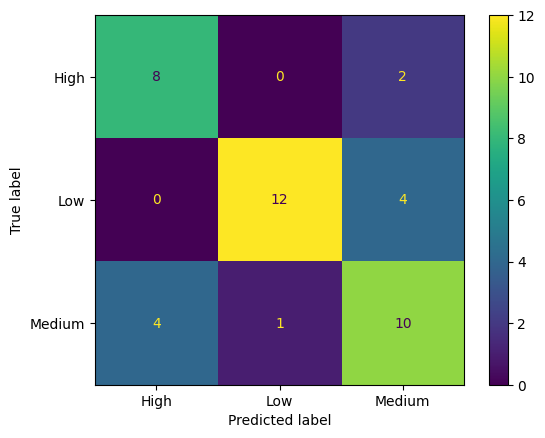

In [13]:
set_config(transform_output="pandas")

df = pd.read_csv("support.csv")

X = df.drop(columns="priority")
y = df["priority"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

preprocess = ColumnTransformer(
    transformers=[
        ("categories", OneHotEncoder(sparse_output=False), ["customer_tier", "issue_type"]),
        ("text_categories", TfidfVectorizer(), "ticket_text"),
        ("num", StandardScaler(), ['response_time_hours'])
    ],
    sparse_threshold=0
)

pipe = Pipeline(
    [
        ("prep", preprocess),
        ("model", LogisticRegression(random_state=42)),
    ]
)

model = GridSearchCV(
    estimator=pipe,
    param_grid={"model__max_iter": [300]},
    scoring=["precision_weighted", "recall_weighted", "f1_weighted"],
    refit="recall_weighted",
    cv=5,
)

model.fit(X_train, y_train)

model_predictions = model.predict(X_test)

score = accuracy_score(y_test, model_predictions,)
print(f"Accuracy: {score * 100:.2f}")

recall = recall_score(y_test, model_predictions, average='macro')
print(f"Recall: {recall * 100:.2f}")

classification = classification_report(y_test, model_predictions)
print(f"Classification report: {classification}")

cm = confusion_matrix(y_test, model_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['High', 'Low', 'Medium'])

disp.plot()
plt.show()

Standard precision and recall are "binary," meaning they only work when you have two options (Yes/No). Because you have three ('high', 'low', 'medium'), scikit-learn doesn't know which one is the "success" and which is the "failure." I also made use of the tfidf for encoding my columns that is made up of text

Accuracy: 82.93
Recall: 83.61
Classification report:               precision    recall  f1-score   support

        high       0.75      0.90      0.82        10
         low       0.93      0.88      0.90        16
      medium       0.79      0.73      0.76        15

    accuracy                           0.83        41
   macro avg       0.82      0.84      0.83        41
weighted avg       0.83      0.83      0.83        41



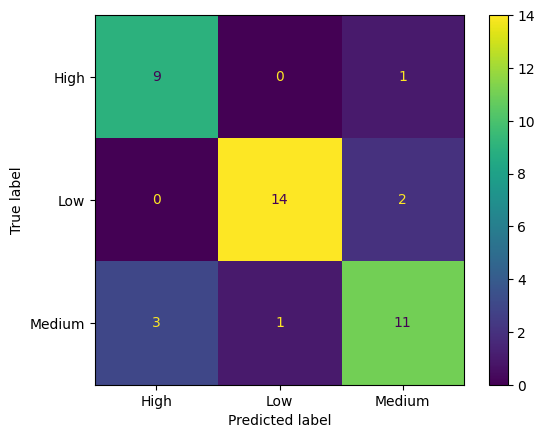

In [10]:
set_config(transform_output="pandas")

df = pd.read_csv("support.csv")

X = df.drop(columns="priority")
y = df["priority"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

preprocess = ColumnTransformer(
    transformers=[
        ("categories", OneHotEncoder(sparse_output=False), ["customer_tier", "issue_type"]),
        ("text_categories", TfidfVectorizer(), "ticket_text"),
        ("num", StandardScaler(), ['response_time_hours'])
    ],
    sparse_threshold=0
)

pipe = Pipeline(
    [
        ("prep", preprocess),
        ("model", RandomForestClassifier(random_state=42)),
    ]
)

model = GridSearchCV(
    estimator=pipe,
    param_grid={
       'model__n_estimators': [10, 15],
       'model__max_depth': [15],
       'model__min_samples_split': [15]
        },
    scoring=["precision_weighted", "recall_weighted"],
    refit="recall_weighted",
    cv=5,
)

model.fit(X_train, y_train)

model_predictions = model.predict(X_test)

score = accuracy_score(y_test, model_predictions,)
print(f"Accuracy: {score * 100:.2f}")

recall = recall_score(y_test, model_predictions, average='macro')
print(f"Recall: {recall * 100:.2f}")

classification = classification_report(y_test, model_predictions)
print(f"Classification report: {classification}")

cm = confusion_matrix(y_test, model_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['High', 'Low', 'Medium'])

disp.plot()
plt.show()


So today i learnt about tdidf vertorizer used mainly for text.

then for multiclass classifer you don;t use recall and precison alone you add weighted and for the recall score method you add average=macro
random forest performed better